In [6]:
from PIL import Image
import matplotlib.pyplot as plt
%matplotlib inline

from strhub.data.module import SceneTextDataModule
from strhub.models.utils import load_from_checkpoint

ckpt = "/home/abhinavchadaga/cs/fri_II/final_project/trained_weights/parseq_label_str_trained_weights.ckpt"

# Load model and image transforms
parseq = load_from_checkpoint(checkpoint_path=ckpt)
img_transform = SceneTextDataModule.get_transform(parseq.hparams.img_size)

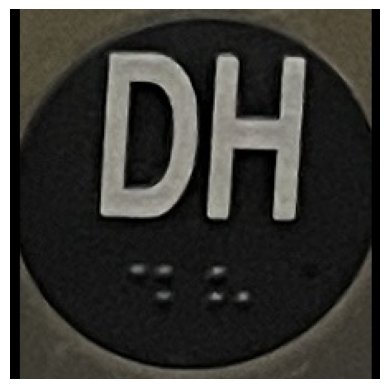

In [7]:
img_path = "/home/abhinavchadaga/cs/fri_II/final_project/data/labels/val/ahg_0_DH.jpg"
img = Image.open(img_path).convert('RGB')
plt.imshow(img)
plt.axis("off")
plt.show()

# Preprocess. Model expects a batch of images with shape: (B, C, H, W)
img = img_transform(img).unsqueeze(0)

In [10]:
logits = parseq(img)
logits.shape  # torch.Size([1, 26, 95]), 94 characters + [EOS] symbol

tensor([[[ -0.9455,   0.2561,   0.5371,  ...,  -4.9113, -11.8913,  -8.1821],
         [  5.2848,  -0.3973,  -1.0533,  ...,  -1.9363,  -5.0636,  -7.6258],
         [ 11.9017,   0.0723,   2.7239,  ...,   0.2565,  -4.5924,  -2.2717],
         ...,
         [  2.7280,   0.9832,  -0.3522,  ...,  -3.5349,  -6.3564,  -3.5729],
         [  2.3530,   0.3357,  -2.4383,  ...,  -1.5998,  -5.5505,  -2.3739],
         [ 10.7955,  -1.0535,   0.2596,  ...,  -0.8784,  -3.6419,  -2.9326]]],
       grad_fn=<ViewBackward0>)


In [19]:
pred = logits.softmax(-1)
label, confidence = parseq.tokenizer.decode(pred)
print('Decoded label = {}'.format(label[0]))

tensor([[3.5050e-08, 6.5517e-06, 4.8647e-05, 1.1727e-04, 9.9838e-01, 2.3309e-05,
         9.4369e-07, 8.1433e-06, 2.2602e-07, 8.6568e-07, 1.5153e-06, 2.9875e-07,
         6.4101e-06, 1.4100e-07, 2.8402e-06, 2.0880e-05, 4.7717e-06, 1.0652e-07,
         1.4276e-06, 1.9051e-04, 2.9723e-05, 2.4966e-07, 1.9751e-05, 9.0763e-07,
         3.9333e-07, 5.0057e-07]], grad_fn=<SliceBackward0>)
Decoded label = DH
